In [1]:
import pandas as pd

print(pd.__version__)

3.0.5


In [2]:
import pandas as pd

df = pd.read_csv("../../data_pipeline/books.csv")

df.head()

,title,price,availability,rating,category
0,A Light in the Attic,51.77,In stock,3,Poetry
1,Tipping the Velvet,53.74,In stock,1,Historical Fiction
2,Soumission,50.10,In stock,1,Fiction
3,Sharp Objects,47.82,In stock,4,Mystery
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,History


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         60 non-null     str    
 1   price         60 non-null     float64
 2   availability  60 non-null     str    
 3   rating        60 non-null     int64  
 4   category      60 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 2.5 KB


In [4]:
df.describe()

,price,rating
count,60.000000,60.000000
mean,35.002667,3.000000
std,14.553082,1.507046
min,12.840000,1.000000
25%,22.040000,1.750000
50%,33.485000,3.000000
75%,50.142500,4.000000
max,57.310000,5.000000


In [5]:
df["rating"].value_counts().sort_index()

rating
1    15
2     8
3    13
4    10
5    14
Name: count, dtype: int64

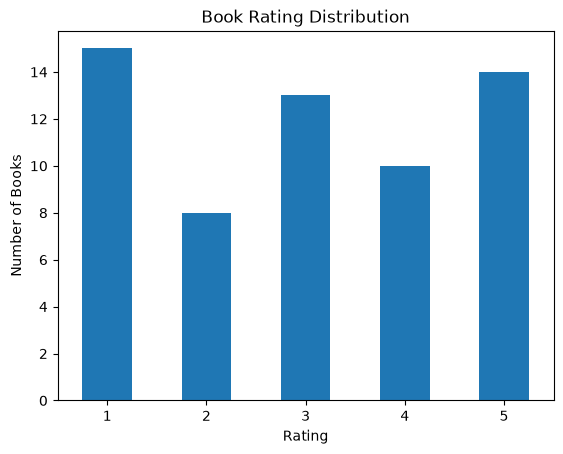

In [6]:
import matplotlib.pyplot as plt

rating_counts = df["rating"].value_counts().sort_index()

rating_counts.plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.show()

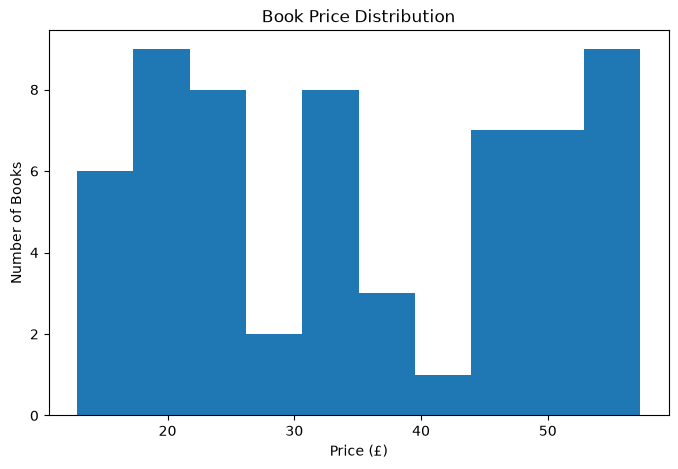

In [7]:
plt.figure(figsize=(8, 5))

df["price"].plot(kind="hist", bins=10)

plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

In [8]:
avg_price_by_category = (
    df.groupby("category")["price"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_by_category

category
Historical Fiction    53.740000
Politics              51.330000
Childrens             49.220000
Travel                45.170000
New Adult             45.070000
Art                   44.180000
Food and Drink        43.465000
Music                 43.196667
Mystery               41.316667
Fiction               41.312500
History               39.875000
Science Fiction       37.590000
Poetry                36.238571
Business              33.340000
Contemporary          31.770000
Nonfiction            30.751429
Romance               29.900000
Thriller              29.626667
Sequential Art        29.353333
Young Adult           28.443333
Default               25.922857
Fantasy               18.780000
Spirituality          17.660000
Philosophy            15.940000
Name: price, dtype: float64

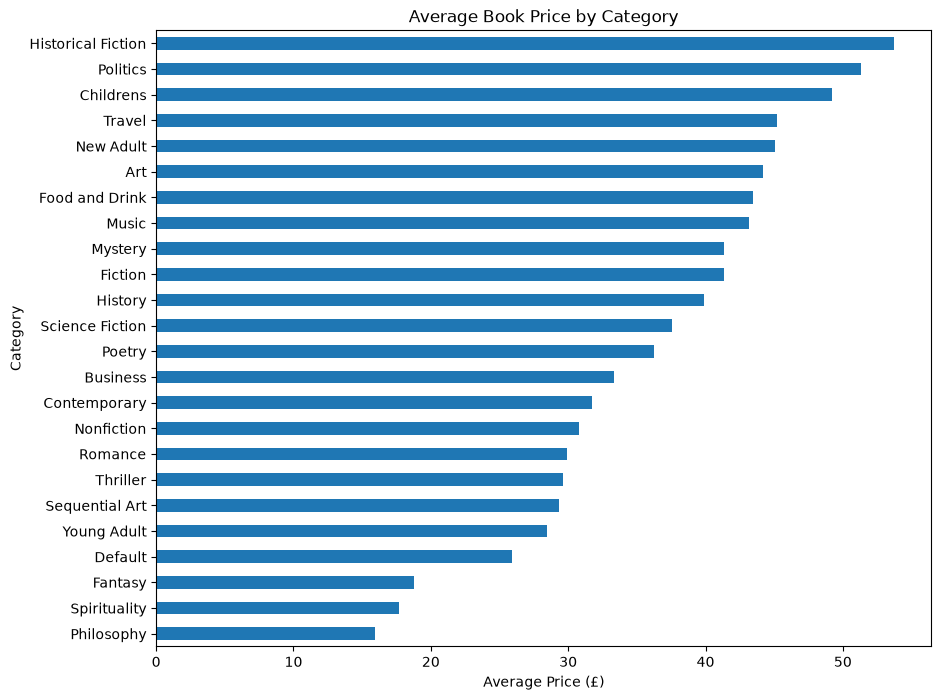

In [9]:
plt.figure(figsize=(10, 8))

avg_price_by_category.plot(kind="barh")

plt.title("Average Book Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.show()

In [10]:
avg_rating_by_category = (
    df.groupby("category")["rating"]
      .mean()
      .sort_values(ascending=False)
)

avg_rating_by_category

category
Romance               5.000000
Spirituality          5.000000
Philosophy            5.000000
Art                   4.000000
Fiction               4.000000
Business              4.000000
Music                 3.333333
Sequential Art        3.333333
Thriller              3.333333
Nonfiction            3.285714
Young Adult           3.000000
History               3.000000
Fantasy               3.000000
Mystery               3.000000
Default               2.857143
Poetry                2.571429
Travel                2.000000
Politics              2.000000
Food and Drink        2.000000
New Adult             2.000000
Childrens             1.666667
Contemporary          1.000000
Historical Fiction    1.000000
Science Fiction       1.000000
Name: rating, dtype: float64

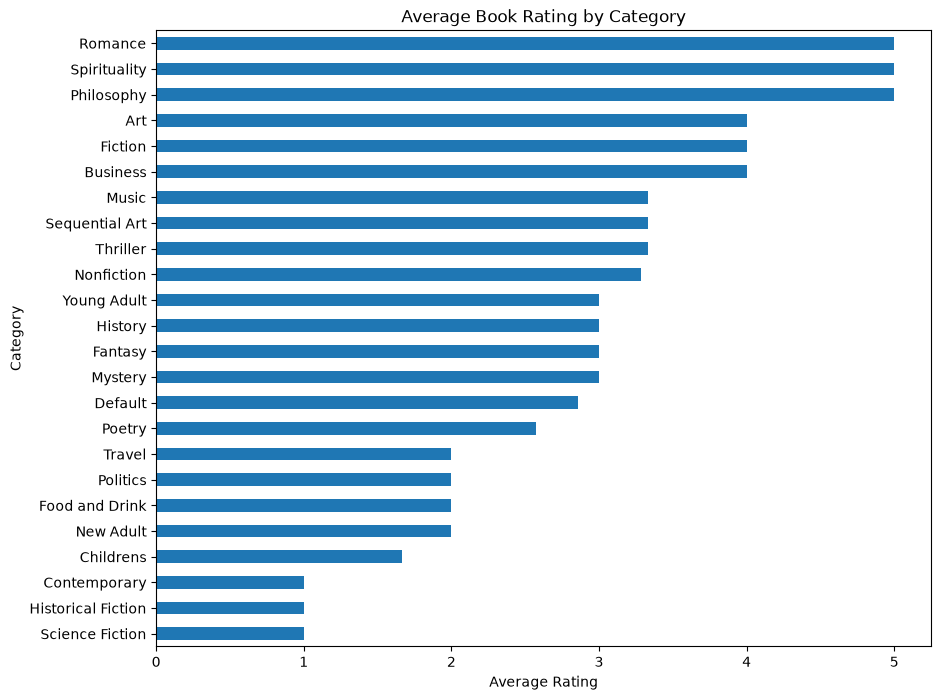

In [11]:
plt.figure(figsize=(10, 8))

avg_rating_by_category.plot(kind="barh")

plt.title("Average Book Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.show()

In [12]:
cheapest_book = df.loc[df["price"].idxmin()]
most_expensive_book = df.loc[df["price"].idxmax()]

print("Cheapest Book:")
print(cheapest_book)

print("\nMost Expensive Book:")
print(most_expensive_book)

Cheapest Book:
title           In Her Wake
price                 12.84
availability       In stock
rating                    1
category           Thriller
Name: 20, dtype: object

Most Expensive Book:
title           Slow States of Collapse: Poems
price                                    57.31
availability                          In stock
rating                                       3
category                                Poetry
Name: 40, dtype: object


In [13]:
print("Average Book Price:", df["price"].mean())
print("Average Book Rating:", df["rating"].mean())

Average Book Price: 35.00266666666667
Average Book Rating: 3.0


In [14]:
availability_counts = df["availability"].value_counts()
availability_counts

availability
In stock    60
Name: count, dtype: int64

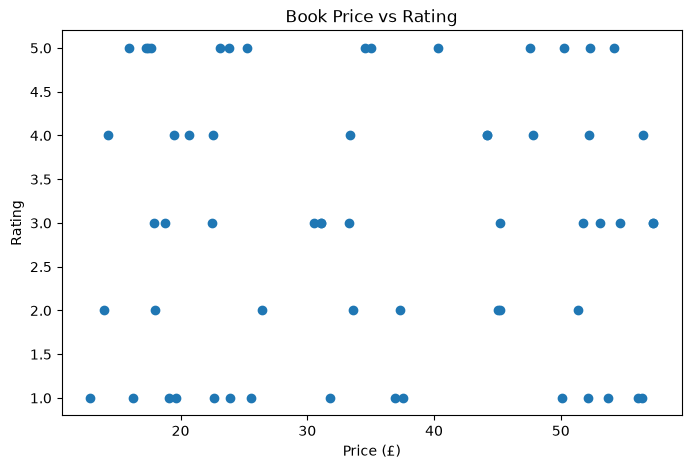

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df["price"], df["rating"])
plt.title("Book Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")
plt.show()

In [ ]:
print("Average Book Price:", df["price"].mean())
print("Average Book Rating:", df["rating"].mean())

Average Book Price: 35.00266666666667
Average Book Rating: 3.0


In [16]:
price_rating_correlation = df["price"].corr(df["rating"])

print("Price-Rating Correlation:", price_rating_correlation)

Price-Rating Correlation: -0.02740345630939448
